In [51]:
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import logging

logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

solar_config_path = Path('config/arctic_cloud_experiment_solar.yaml')
thermal_config_path = Path('config/arctic_cloud_experiment_thermal.yaml')


| Surface type        | Shortwave albedo α (broadband) | Longwave emissivity ε (8–13 µm) | Notes / typical use |
|---------------------|--------------------------------|----------------------------------|---------------------|
| Open water          | 0.05 – 0.10                    | 0.985 – 0.990                    | Low SW reflectance; near-blackbody in TIR |
| Thin ice (nilas / young ice) | 0.15 – 0.40            | 0.970 – 0.985                    | Strong thickness dependence; key for leads |
| Snow-covered sea ice| 0.75 – 0.90                    | 0.980 – 0.995                    | Very high SW albedo; excellent LW emitter |


In [52]:
albedos_sw = [0.07, 0.3, 0.75, .9]
albedos_lw = [1 - 0.987, 1 - 0.985, 1 - 0.98, 1 - 0.991] # 1 - emissivity ... naja

# libradtran handles emissivity = 1 - albedo ; 

In [ ]:
# Define a simple profile
# z: 2km to 1km (descending required by uvspec)
# 

lwcs = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50]
reffs = [10]
surface_temperatures = [273.15, 273.15 - 5, 253.15 - 20, 273.15 - 25]
cbh = [0.5] * len(lwcs)
cth = [1.5] * len(lwcs)
# add a low-level cloud with varying LWC
times = pd.date_range("2024-04-04 12:00", periods=1, freq="h")
lats = [78] * len(times)
lon = [0] * len(times)
altitudes = np.arange(0, 10, 1)

ds = xr.Dataset(
    coords={
        "time": times, 
        "latitude": (("time",), lats), 
        "longitude": (("time",), lon),
        "altitude": (("altitude",), altitudes)
    },
    data_vars={
        "lwc": (("lwc",), lwcs),
        "reff": (("reff",), reffs),
        "cth": (("lwc",), cth),
        "cbh": (("lwc",), cbh),
        "surface_temperature": (("albedo",), surface_temperatures),
        "albedo_sw": (("albedo",), albedos_sw),
        "albedo_lw": (("albedo",), albedos_lw),
        #"sza": (("sza",), [50, 60, 70, 80, 90]) # Optional
    }
)

ds_sim_no_cloud_solar = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_solar.yaml',
    surface_temperature_var='surface_temperature',
    albedo_var='albedo_sw',
    #surface_type_var='surface_type',
    save_to_file=False, 
    return_dataset=True,
)

ds_sim_no_cloud_thermal = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_thermal.yaml',
    surface_temperature_var='surface_temperature',
    albedo_var='albedo_lw',
    #surface_type_var='surface_type',
    save_to_file=False, 
    return_dataset=True,
)

ds_sim_cloudy_solar = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_solar.yaml',
    cloud_wc_var='lwc',
    cloud_reff_var='reff',
    cloud_top_var='cth',
    cloud_bottom_var='cbh',
    surface_temperature_var='surface_temperature',
    albedo_var='albedo_sw',
    #surface_type_var='surface_type',
    save_to_file=False, 
    return_dataset=True,
)

ds_sim_cloudy_thermal = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_thermal.yaml',
    cloud_wc_var='lwc',
    cloud_reff_var='reff',
    cloud_top_var='cth',
    cloud_bottom_var='cbh',
    surface_temperature_var='surface_temperature',
    albedo_var='albedo_lw',
    #surface_type_var='surface_type',
    save_to_file=False, 
    return_dataset=True,
)   

2025-12-13 18:09:48,095 - pyradtran.config - WARNING - Ignoring unknown config parameter: variable_encoding in OutputConfig


Running simulations:   0%|          | 0/60 [00:00<?, ?sim/s]

In [4]:
ds_sim_no_cloud_solar_normed = ds_sim_no_cloud_solar / 1000
ds_sim_cloudy_solar_normed = ds_sim_cloudy_solar / 1000
ds_cre_solar = ds_sim_cloudy_solar_normed - ds_sim_no_cloud_solar_normed
ds_cre_thermal = ds_sim_cloudy_thermal - ds_sim_no_cloud_thermal
ds_cre_total = ds_cre_solar + ds_cre_thermal

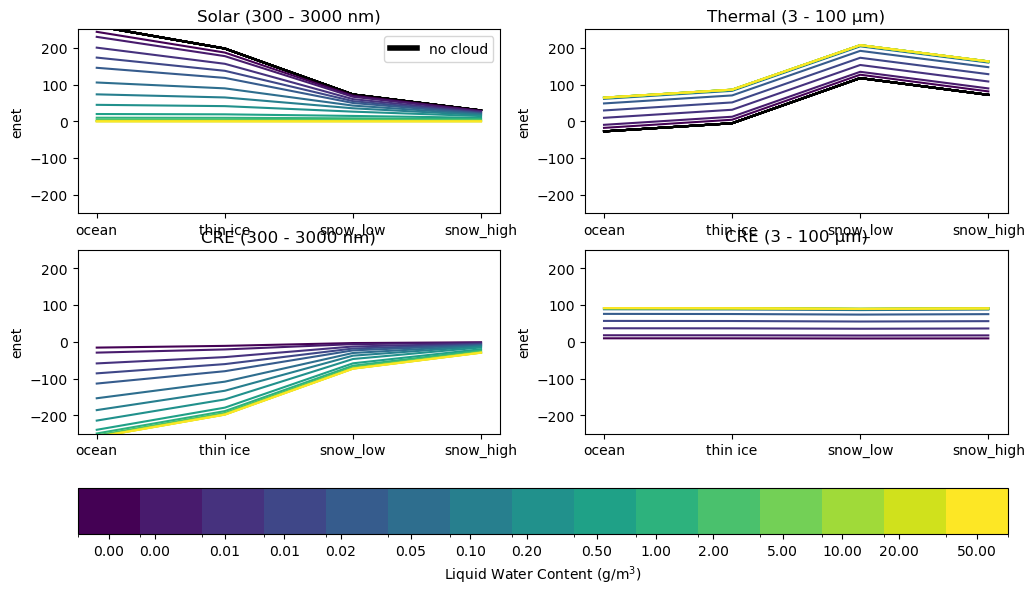

In [50]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7,))
from cycler import cycler

# change lwc hue with cycler to virdis colors
ax[0, 0].set_prop_cycle(cycler('color', plt.cm.viridis(np.linspace(0, 1, len(ds_sim_no_cloud_solar.lwc)))))
ax[0, 1].set_prop_cycle(cycler('color', plt.cm.viridis(np.linspace(0, 1, len(ds_sim_no_cloud_thermal.lwc)))))

(ds_sim_no_cloud_solar.isel(altitude=0).enet / 1000).plot(hue='lwc', color='k', ax=ax[0, 0], add_legend=False)
(ds_sim_cloudy_solar.isel(altitude=0).enet / 1000).plot(hue='lwc', label='cloudy', ax=ax[0, 0], add_legend=False)
ax[0,0].set_title('Solar (300 - 3000 nm)')

ds_sim_no_cloud_thermal.isel(altitude=0).enet.plot(hue='lwc', color='k', ax=ax[0, 1], add_legend=False)
ds_sim_cloudy_thermal.isel(altitude=0).enet.plot(hue='lwc', label='cloudy', ax=ax[0, 1], add_legend=False)
ax[0,1].set_title('Thermal (3 - 100 µm)')

ax[1, 0].set_prop_cycle(cycler('color', plt.cm.viridis(np.linspace(0, 1, len(ds_sim_no_cloud_solar.lwc)))))
ax[1, 1].set_prop_cycle(cycler('color', plt.cm.viridis(np.linspace(0, 1, len(ds_sim_no_cloud_solar.lwc)))))


ds_cre_solar.isel(altitude=0).enet.plot(hue='lwc', ax=ax[1, 0], add_legend=False)
ds_cre_thermal.isel(altitude=0).enet.plot(hue='lwc', label='cloudy', ax=ax[1, 1], add_legend=False)
ax[1,1].set_title('CRE (3 - 100 µm)')
ax[1,0].set_title('CRE (300 - 3000 nm)')



# add a colorbar to the bottom of the figure
import matplotlib.colors as mcolors

lwc_values = ds_sim_no_cloud_solar.lwc.values
n_colors = len(lwc_values)

# Create a colormap with discrete colors based on the viridis cycler
colors = plt.cm.viridis(np.linspace(0, 1, n_colors))
discrete_cmap = mcolors.ListedColormap(colors)

# Create boundaries for the discrete colormap
# Assuming lwc_values are ordered, calculate midpoints for boundaries
# If lwc_values are not ordered, sort them first: lwc_values.sort()
if n_colors > 1:
    boundaries = np.concatenate(([lwc_values[0] - (lwc_values[1] - lwc_values[0]) / 2],
                                 (lwc_values[:-1] + lwc_values[1:]) / 2,
                                 [lwc_values[-1] + (lwc_values[-1] - lwc_values[-2]) / 2]))
else: # Handle case with a single LWC value
    boundaries = np.array([lwc_values[0] - 0.5, lwc_values[0] + 0.5])


norm = mcolors.BoundaryNorm(boundaries, discrete_cmap.N, clip=True)

sm = plt.cm.ScalarMappable(cmap=discrete_cmap, norm=norm)
sm.set_array([]) # Required for ScalarMappable when not directly plotting data

cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.15, pad=0.1, ticks=lwc_values)
cbar.set_label('Liquid Water Content (g/m$^3$)')

x_labels = ['ocean', 'thin ice', 'snow_low', 'snow_high']
x_ticks = np.arange(len(x_labels))

# add only a legend for the black line
handels = [plt.Line2D([0], [0], color='k', lw=4)]
labels = ['no cloud']
ax[0,0].legend(handels, labels, loc='upper right', ncol=1)

for a in ax.flatten():
    a.set_xticks(x_ticks)
    a.set_xticklabels(x_labels)
    a.set_xlabel('')
    a.set_ylim(-250, 250)   

Now to the cool part: We show what effect the cloud has on the surface net radiation, dependiing on the surface type.

Text(0.5, 0, '')

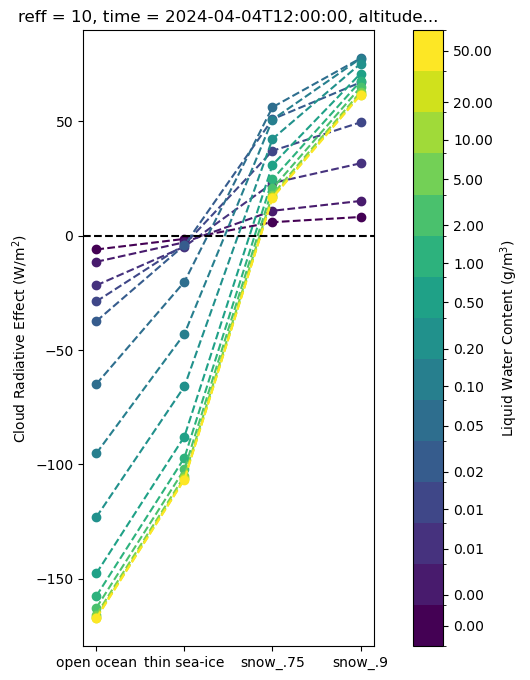

In [49]:
fig, ax = plt.subplots(figsize=(5, 8))

ax.set_prop_cycle(cycler('color', plt.cm.viridis(np.linspace(0, 1, len(ds_sim_no_cloud_solar.lwc)))))


ds_cre_total.isel(altitude=0).enet.plot(hue='lwc', marker='o', ax=ax, ls='--', add_legend=False )


ax.axhline(y=0, color='black', linestyle='--')

ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['open ocean', 'thin sea-ice', 'snow_.75', 'snow_.9'])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.15, pad=0.1, ticks=lwc_values)
cbar.set_label('Liquid Water Content (g/m$^3$)')
ax.set_ylabel('Cloud Radiative Effect (W/m$^2$)')
ax.set_xlabel('')


In [ ]:
ds

<xarray.Dataset> Size: 200B
Dimensions:              (lwc: 2, reff: 2, albedo: 2, time: 1, altitude: 10)
Coordinates:
  * lwc                  (lwc) float64 16B 0.01 10.0
  * reff                 (reff) int64 16B 5 25
  * albedo               (albedo) float64 16B 0.2 0.9
  * time                 (time) datetime64[ns] 8B 2024-04-04T12:00:00
    latitude             (time) int64 8B 78
    longitude            (time) int64 8B 0
  * altitude             (altitude) int64 80B 0 1 2 3 4 5 6 7 8 9
Data variables:
    cth                  (lwc) float64 16B 1.5 1.5
    cbh                  (lwc) float64 16B 0.5 0.5
    surface_temperature  (albedo) float64 16B 273.1 273.1

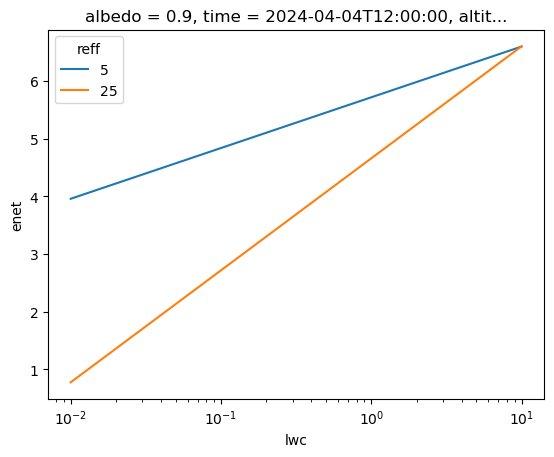

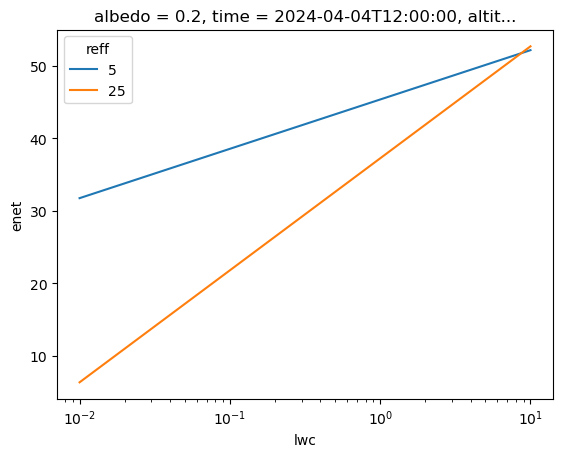

In [ ]:
ds_sim.isel(time=0,altitude=0,albedo=1).enet.plot(hue='reff')
plt.xscale('log')
plt.show()

ds_sim.isel(time=0,altitude=0,albedo=0).enet.plot(hue='reff')
plt.xscale('log')
plt.show()


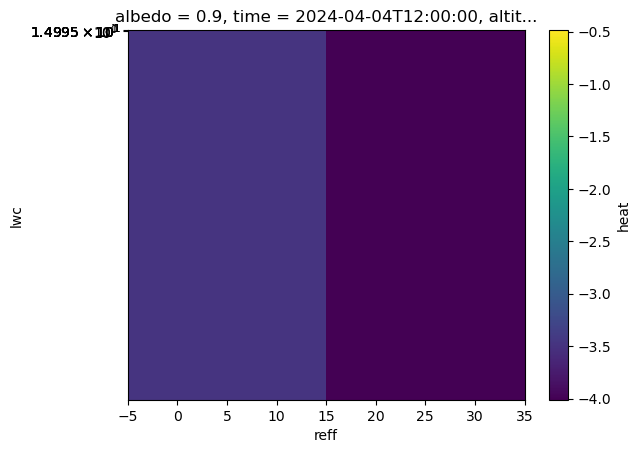

In [ ]:
ds_sim.heat.isel(altitude=0, albedo=1).plot()
plt.yscale('log')
#ds_sim.enet.isel(time=0, lwc=1).plot(hue='sza')